# Differential Equations for Machine Learning
## Notebook 01 — From ODEs to Numerical Simulation

### Objective

In this notebook, we will build the mathematical foundation required to understand
Physics-Informed Neural Networks (PINNs).

We will learn:

1. What a differential equation is
2. What an Ordinary Differential Equation (ODE) means
3. What a derivative represents
4. Initial conditions
5. Analytical solutions
6. Numerical solutions
7. How `scipy.integrate.solve_ivp()` solves an ODE
8. Visualizing the solution
9. Understanding the connection between ODEs and neural networks

We will begin with a very simple differential equation:

    dy/dt = 2y

with the initial condition:

    y(0) = 1

This simple equation will later become the foundation for understanding PINNs.

# 1. What is a Differential Equation?

A differential equation is an equation involving an unknown function and one or
more of its derivatives.

For example:

    dy/dt = 2y

Here:

- `y` is an unknown function
- `t` is the independent variable
- `dy/dt` is the derivative of `y` with respect to `t`

The derivative tells us how quickly `y` is changing.

So:

    dy/dt = 2y

means:

> The rate of change of `y` is proportional to its current value.

This is fundamentally different from an ordinary algebraic equation.

An algebraic equation might tell us:

    y = 2t

A differential equation instead tells us a rule describing how `y` changes:

    dy/dt = 2y

We must solve the differential equation to obtain the actual function `y(t)`.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)

NumPy version: 2.2.6


# 2. Understanding the Derivative

Before solving an ODE, we need an intuitive understanding of a derivative.

Suppose we have:

    y = t²

The derivative is:

    dy/dt = 2t

The derivative tells us the slope of the function at every point.

For example:

    t = 1  →  dy/dt = 2
    t = 2  →  dy/dt = 4
    t = 3  →  dy/dt = 6

Therefore, the derivative describes the instantaneous rate of change.

This idea is extremely important for PINNs because a neural network can produce
a prediction `y(t)`, and automatic differentiation can calculate:

    d(y_prediction)/dt

That allows us to check whether the neural network obeys a differential equation.

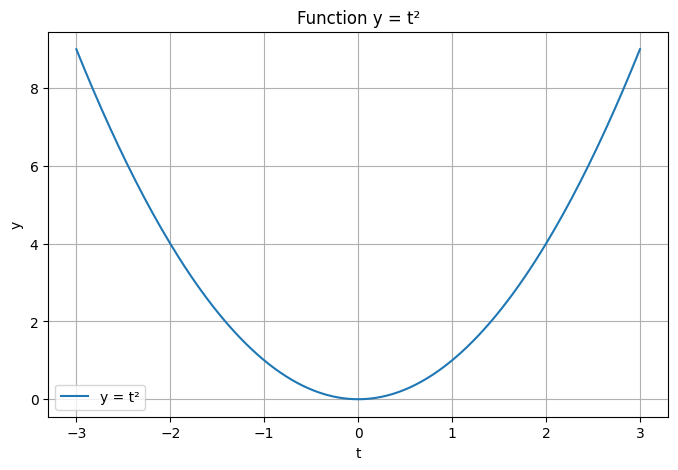

In [4]:
# Define t values
t = np.linspace(-3, 3, 200)

# Function
y = t**2

# Analytical derivative
dy_dt = 2 * t

# Plot the function
plt.figure(figsize=(8, 5))
plt.plot(t, y, label="y = t²")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Function y = t²")
plt.grid(True)
plt.legend()
plt.show()

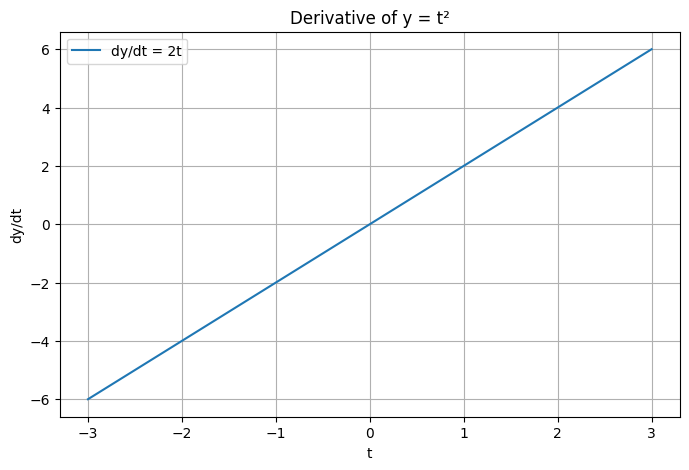

In [5]:
# Plot the derivative
plt.figure(figsize=(8, 5))
plt.plot(t, dy_dt, label="dy/dt = 2t")
plt.xlabel("t")
plt.ylabel("dy/dt")
plt.title("Derivative of y = t²")
plt.grid(True)
plt.legend()
plt.show()

# 3. Our First ODE

Now consider:

    dy/dt = 2y

This equation says:

    rate of change = 2 × current value

We also need an initial condition:

    y(0) = 1

The initial condition tells us where the solution starts.

Without an initial condition, the differential equation has infinitely many solutions.

For this particular equation, the analytical solution is:

    y(t) = e^(2t)

Let's verify this.

If:

    y(t) = e^(2t)

then:

    dy/dt = 2e^(2t)

Since:

    y = e^(2t)

we get:

    dy/dt = 2y

Therefore the function satisfies the differential equation.

The initial condition also works:

    y(0) = e^0 = 1

So:

    y(t) = e^(2t)

is the solution to:

    dy/dt = 2y
    y(0) = 1

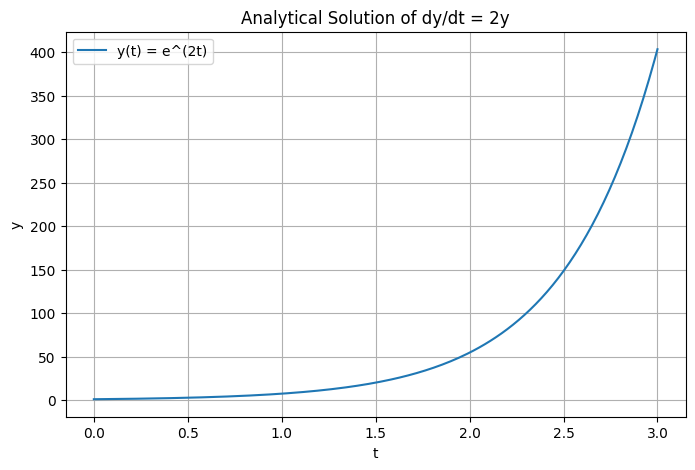

In [6]:
# Analytical solution of dy/dt = 2y, y(0) = 1

t = np.linspace(0, 3, 200)

y = np.exp(2 * t)

plt.figure(figsize=(8, 5))
plt.plot(t, y, label="y(t) = e^(2t)")
plt.xlabel("t")
plt.ylabel("y")
plt.title("Analytical Solution of dy/dt = 2y")
plt.grid(True)
plt.legend()
plt.show()

# 4. Why Do We Need Numerical Methods?

For simple equations, we can sometimes find an analytical solution.

But many real-world differential equations are too complicated to solve exactly.

For example, the Lorenz system is:

    dx/dt = σ(y - x)

    dy/dt = x(ρ - z) - y

    dz/dt = xy - βz

This system does not have a simple closed-form solution.

Therefore, computers use numerical methods to approximate the solution.

The general idea is:

    Differential Equation
            ↓
    Numerical Algorithm
            ↓
    Approximate Solution
            ↓
    Values of x(t), y(t), z(t)

Python provides powerful numerical ODE solvers through SciPy.

In [7]:
import scipy
from scipy.integrate import solve_ivp

print("SciPy version:", scipy.__version__)

SciPy version: 1.15.3


# 5. Solving an ODE Numerically with SciPy

We will solve:

    dy/dt = 2y

with:

    y(0) = 1

`solve_ivp()` expects a function representing the differential equation.

The function should have the form:

    f(t, y)

and return:

    dy/dt

So we define:

    dy/dt = 2y

In [8]:
def ode_function(t, y):
    """
    Defines the differential equation:

        dy/dt = 2y

    Parameters
    ----------
    t : float
        Current time.
        
    y : array-like
        Current value of y.

    Returns
    -------
    array-like
        Derivative dy/dt.
    """
    
    return 2 * y

In [9]:
# Initial condition
y0 = [1]

# Time interval
t_span = (0, 3)

# Points where we want the solution
t_eval = np.linspace(0, 3, 200)

# Solve the ODE
solution = solve_ivp(
    ode_function,
    t_span,
    y0,
    t_eval=t_eval
)

print("Time values:")
print(solution.t[:5])

print("\nSolution values:")
print(solution.y[0][:5])

Time values:
[0.         0.01507538 0.03015075 0.04522613 0.06030151]

Solution values:
[1.         1.0306099  1.06215677 1.09466926 1.12817696]


# 6. Understanding the `solve_ivp()` Output

The important attributes are:

    solution.t

and:

    solution.y

`solution.t` contains the time values.

`solution.y` contains the corresponding solution values.

For our equation:

    solution.y[0][i]

represents the value of `y` at:

    solution.t[i]

So we have approximately:

    t₀ → y₀
    t₁ → y₁
    t₂ → y₂
    ...

This gives us a collection of points representing the solution.


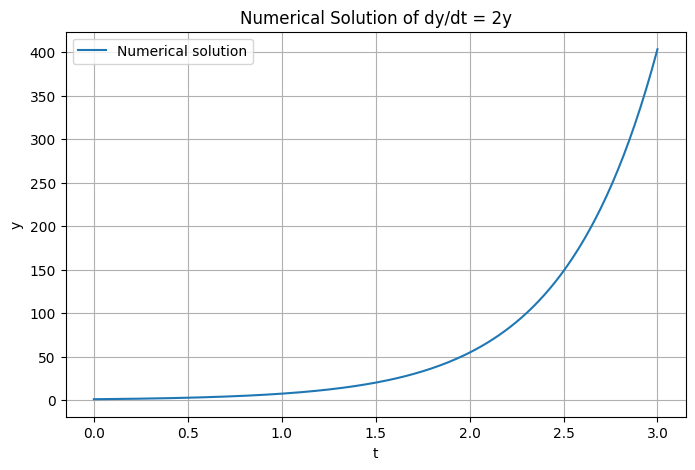

In [10]:
# Extract numerical solution
t_numeric = solution.t
y_numeric = solution.y[0]

# Plot numerical solution
plt.figure(figsize=(8, 5))

plt.plot(
    t_numeric,
    y_numeric,
    label="Numerical solution"
)

plt.xlabel("t")
plt.ylabel("y")
plt.title("Numerical Solution of dy/dt = 2y")
plt.grid(True)
plt.legend()

plt.show()